In [4]:
import sys,os
sys.path.append('../../')
os.environ["JAX_PLATFORMS"] = "cpu"
import matplotlib.pyplot as plt
import numpy as np
from utils import makefolder,depths,reduce_list_half_preserve_extremes

from geometry import * 

eps = 1E-7
rcpsize = 14
plt.rcParams['xtick.labelsize']= rcpsize
plt.rcParams['ytick.labelsize']=rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': True})
#colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = plt.cm.tab20.colors  # 20 distinct colors
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
# print(plt.rcParams.keys())
#np.set_printoptions(precision=None)
markers = ['p','o','h','^','s','*']
_linestyles = ['-','--','dotted']
plot_id = 0


In [5]:
# modelA = 'deepseek'
# modelA = 'llama8b'
modelA = 'qwen7b'
modelB = modelA
languages = [
            'english',
            'italian',
            'spanish',
            'german',
            'chinese',
            'arabic',
            'turkish',
            ]

batch_shuffle = 0
centers_list = ['syn']
min_token_length = 3
n_files = 16
batch_size = 100
n_tokens_list = [min_token_length]
avg_flags = [0,1]
Nbits_list = [0]
match_vars = ['matching']
data_vars = ['sem']
zero_activations_list = [0]
center_A_flags = [0]
center_B_flags = [0]

[]

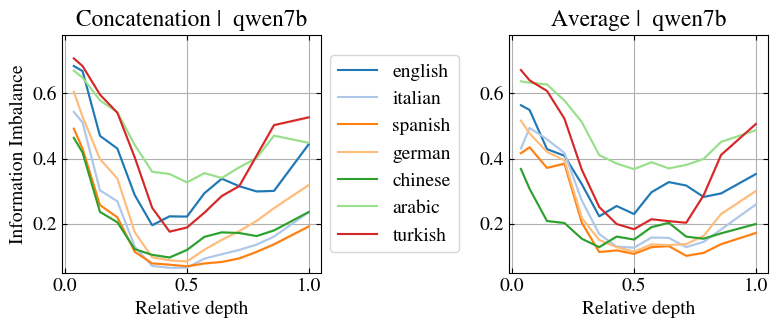

In [6]:
fig,ax = plt.subplots(1,2,figsize=(8,3.5))

for avg_id,avg_tokens in enumerate(avg_flags):
  title = ' '
  plot_id = 0
  for number_of_languages in [None]:
    for zero_id,zero_activations in enumerate(zero_activations_list):
      for center_A_id,center_A_flag in enumerate(center_A_flags):
        for center_B_id,center_B_flag in enumerate(center_B_flags):
          if center_A_flag != center_B_flag: 
            continue
          if center_A_flag == 0 and number_of_languages != None:
            continue
          if center_A_flag != 0 and number_of_languages == None:
            continue
          for data_var_id,data_var in enumerate(data_vars):
            for centers_id,centers in enumerate(centers_list):
              for match_id,match_var in enumerate(match_vars):
                for Nbits_id,Nbits in enumerate(Nbits_list):
                  for language_id, language in enumerate(languages):
                    for n_tokens in n_tokens_list:
                      output_folder0 = makefolder(base=f'./results/',
                                                  global_centering=0,
                                                  spaces='AB',
                                                  similarity_fn='normalized_L2_distance',
                                                  precision=32,
                                                  language=language,
                                                  data_var=data_var,
                                                  modelA=modelA,
                                                  modelB=modelB,
                                                  match_var=match_var,
                                                  n_files=n_files,
                                                  min_token_length=min_token_length,
                                                  )
                      II_folder = makefolder(base=output_folder0,
                                                        centers=centers,
                                                        Nbits=Nbits,
                                                        n_tokens=n_tokens,
                                                        avg_tokens=avg_tokens,
                                                        batch_shuffle=batch_shuffle,
                                                        zero_activations=zero_activations,
                                                        center_A_flag=center_A_flag,
                                                        center_B_flag=center_B_flag,
                                                        number_of_languages=number_of_languages,
                                                        )
                      inf_imb = np.load(II_folder + "II.npy")
                      std = np.load(II_folder + "II_jack_std.npy")

                      layers_A = list(range(1,depths[modelA] + 1))
                      layers_B = list(range(1,depths[modelB] + 1))
                      layers = np.array(reduce_list_half_preserve_extremes(layers_A),dtype=float)
                      layers /= depths[modelB]
                      color = colors[plot_id] 
                      linestyle = '-'
                      if avg_tokens:
                        title = f'Average | '
                      else:
                        title = f'Concatenation | '

                      label = ''
                      if center_A_flag == 0:
                        label += f'{language}'
                      for II_index in range(1):
                        ax[avg_id].plot(layers,
                                inf_imb[II_index].diagonal(),
                                label=label,
                                linestyle=_linestyles[II_index],
                                color=color,
                                ) 
                        ax[avg_id].fill_between(layers,
                                        inf_imb[II_index].diagonal() - std[II_index].diagonal(),
                                        inf_imb[II_index].diagonal() + std[II_index].diagonal(),
                                        alpha=0.2,
                                        color=color,
                                        )
                      plot_id += 1

  ax[avg_id].set_xlabel('Relative depth')
  if avg_id == 0:
    ax[avg_id].set_ylabel('Information Imbalance')
  ax[avg_id].set_title(title + f' {modelA}')

  ax[avg_id].grid()
  ax[avg_id].tick_params(
      top=True, bottom=True, left=True, right=True,  # enable ticks
      labeltop=False, labelbottom=True, labelleft=True, labelright=False, # enable labels if needed
      direction='in'  # ticks point inward
      )
  ax[avg_id].set_ylim(0.05,.78)
box = ax[0].get_position()
ax[0].set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
os.makedirs('results/figs', exist_ok=True)
fig.savefig(f'results/figs/semantic_similarity_{modelA}.pdf', bbox_inches='tight')
plt.plot()